In [25]:
from matplotlib import pyplot as plt
import numpy as np
from scipy.stats import norm

In [16]:
a = np.load("../data/random_sequences/random_sequences.npy")
a = a[3, 0:200]

In [27]:
paa = np.average(a.reshape(20, -1), axis=1)
averages = np.repeat(paa, 10)

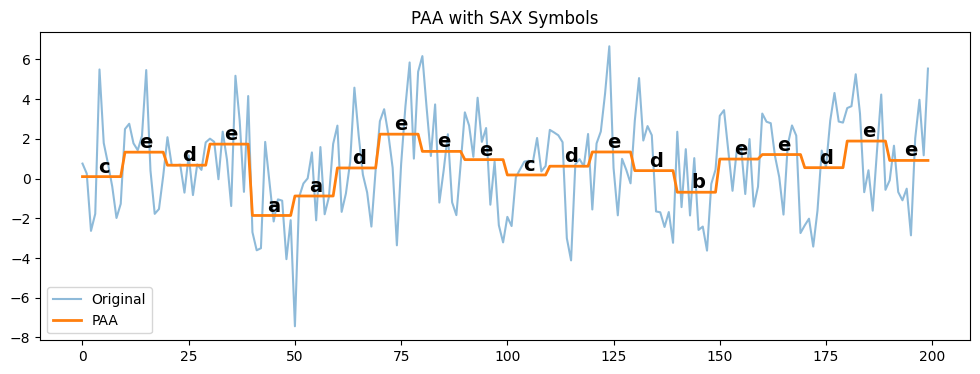

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Example time series
a = np.array(a)

# --- 1. Compute PAA ---
n_segments = 20
segment_size = len(a) // n_segments
paa = np.mean(a.reshape(n_segments, -1), axis=1)

# --- 2. Convert PAA to SAX symbols ---
alphabet_size = 5
alphabet = np.array(list("abcde"))

# Gaussian breakpoints
breakpoints = norm.ppf(np.linspace(0, 1, alphabet_size + 1)[1:-1])

# Digitize PAA values
sax_indices = np.digitize(paa, breakpoints)
sax_symbols = alphabet[sax_indices]

# --- 3. Plot ---
plt.figure(figsize=(12, 4))
plt.plot(a, alpha=0.5, label="Original")

# Plot PAA as step function
paa_expanded = np.repeat(paa, segment_size)
plt.plot(paa_expanded, linewidth=2, label="PAA")

# --- 4. Add SAX symbols ---
for i, symbol in enumerate(sax_symbols):
    center = i * segment_size + segment_size // 2
    plt.text(center, paa[i], symbol,
             ha='center', va='bottom',
             fontsize=14, fontweight='bold')

plt.legend()
plt.title("PAA with SAX Symbols")
plt.show()

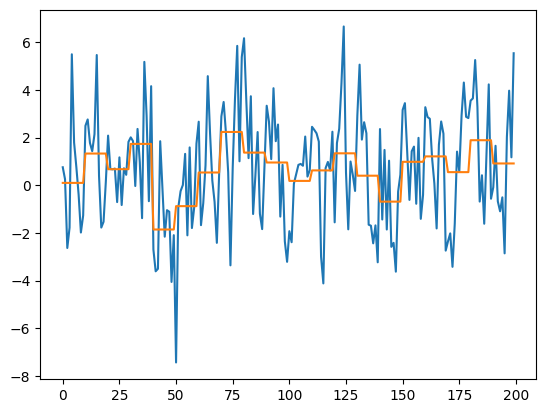

In [23]:
plt.plot(a)
plt.plot(averages)